In [29]:
import warnings, osmnx
warnings.filterwarnings("ignore")

**Importing necessary packages**

In [30]:
import pandas
import osmnx
import geopandas
import rioxarray
import xarray
import datashader
import contextily as cx
from shapely import geometry
import matplotlib.pyplot as plt

**Check your current working directory:**

In [31]:
import os

# Get the current working directory
current_directory = os.getcwd()

# Print the current working directory
print("Current working directory:", current_directory)

Current working directory: /home/wasif/sds/sds


# Part I

## Fundamental geographic data structures

There are a few main data structures that are used in geographic data science: 
- geographic tables (which are generally matched to an object data model), 
- rasters or surfaces (which are generally matched to a field data model), and 
- spatial networks (which are generally matched to a graph data model). 

### Geographic tables

Geographic objects are usually matched to what we called the *geographic table*. Geographic tables can be thought of as a tab in a spreadsheet where one of the columns records geometric information. This data structure represents a single geographic object as a row of a table; each column in the table records information about the object, its attributes or features, as we will see below. Typically, there is a special column in this table that records the *geometry* of the object.

To understand the structure of geographic tables, it will help to read in the `countries_clean.gpkg` dataset included in this course that describes countries in the world. To read in this data, we can use the `read_file()` method in `geopandas`:

In [32]:
import geopandas

gt_polygons = geopandas.read_file("../data/Countries/countries_clean.gpkg")

And we can examine the top of the table with the `.head()` method:

In [33]:
gt_polygons.head()

,ADMIN,geometry
0,Indonesia,"MULTIPOLYGON (((13102705.696 463877.598, 13102..."
1,Malaysia,"MULTIPOLYGON (((13102705.696 463877.598, 13101..."
2,Chile,"MULTIPOLYGON (((-7737827.685 -1979875.5, -7737..."
3,Bolivia,"POLYGON ((-7737827.685 -1979875.5, -7737828.21..."
4,Peru,"MULTIPOLYGON (((-7737827.685 -1979875.5, -7752..."


<div class="alert alert-info">
<span style="font-size:1.5em;">&#9432;</span> 
<strong> What are these `MULTIPOLYGON` and `POLYGON` objects?</strong>
Just continue for now, and we'll discuss them in detail in Part II.
</div>

Geographic tables store geographic information as an additional column. But, how is this information encoded? To see, we can check the type of the object in the first row:

In [34]:
type(gt_polygons.geometry[0])

shapely.geometry.multipolygon.MultiPolygon

In `geopandas` (as well as other packages representing geographic data), the `geometry` column has special traits which a "normal" column, such as `ADMIN`, does not. For example, when we plot the dataframe, the `geometry` column is used as the main shape to use in the plot.

<Axes: >

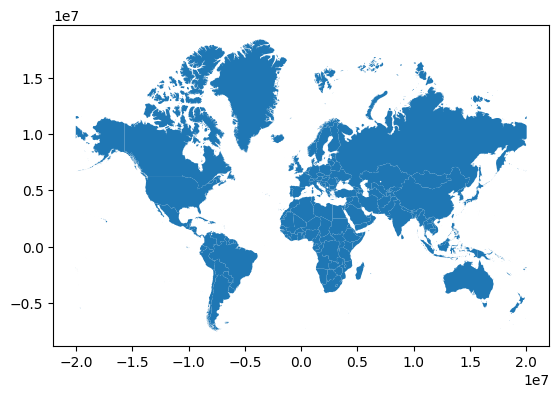

In [35]:
gt_polygons.plot()

Changing the geometric representation of a sample must be done carefully: since the `geometry` column is special, there are special functions to adjust the geometry. For example, if we wanted to represent each country using its *centroid*, a point in the middle of the shape, then we must take care to make sure that a new geometry column was set properly using the `set_geometry()` method. This can be useful when you want to work with two different geometric representations of the same underlying sample. 

Let us make a map of both the boundary and the centroid of a country. First, to compute the centroid, we can use the `gt_polygons.geometry.centroid` property. This gives us the point that minimizes the average distance from all other points on the boundary of the shape. Storing that back to a column, called `centroid`:

In [36]:
gt_polygons["centroid"] = gt_polygons.geometry.centroid

We now have an additional feature:

In [37]:
gt_polygons.head()

,ADMIN,geometry,centroid
0,Indonesia,"MULTIPOLYGON (((13102705.696 463877.598, 13102...",POINT (13055431.81 -248921.141)
1,Malaysia,"MULTIPOLYGON (((13102705.696 463877.598, 13101...",POINT (12211696.493 422897.505)
2,Chile,"MULTIPOLYGON (((-7737827.685 -1979875.5, -7737...",POINT (-7959811.948 -4915458.802)
3,Bolivia,"POLYGON ((-7737827.685 -1979875.5, -7737828.21...",POINT (-7200010.945 -1894653.148)
4,Peru,"MULTIPOLYGON (((-7737827.685 -1979875.5, -7752...",POINT (-8277554.831 -1032942.536)


Despite the fact that `centroid` is a geometry (you can tell because each cell starts with `POINT`), it is not currently set as the active geometry for our table. We can switch to the `centroid` column using the `set_geometry()` method. Finally, we can plot the centroid and the boundary of each country after switching the geometry column with `set_geometry()`:

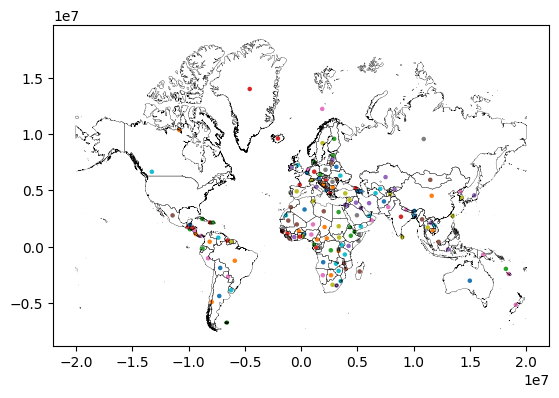

In [38]:
# Plot centroids
ax = gt_polygons.set_geometry("centroid").plot("ADMIN", markersize=5)
# Plot polygons without color filling
gt_polygons.plot(
    "ADMIN", ax=ax, facecolor="none", edgecolor="black", linewidth=0.2
);

Note again how we can create a map by calling `.plot()` on a `GeoDataFrame`. We can thematically color each feature based on a column by passing the name of that column to the plot method (as we do on with `ADMIN` in this case), and that the current geometry is used.

Thus, as should now be clear, nearly any kind of geographic object can be represented in one (or more) geometry column(s). Thinking about the number of different kinds of shapes or geometries one could use quickly boggles the mind. Fortunately the Open Geospatial Consortium (OGC) has defined a set of "abstract" types that can be used to define any kind of geometry. This specification, codified in ISO 19125-1---the "simple features" specification---defines the formal relationships between these types: a `Point` is a zero-dimensional location with an x and y coordinate, a `LineString` is a path composed of a set of more than one `Point`, and a `Polygon` is a surface that has at least one `LineString` that starts and stops with the same coordinate. All of these types *also* have `Multi` variants that indicate a collection of multiple geometries of the same type. So, for instance, Bolivia is represented as a single polygon:

In [39]:
gt_polygons.query('ADMIN == "Bolivia"')

,ADMIN,geometry,centroid
3,Bolivia,"POLYGON ((-7737827.685 -1979875.5, -7737828.21...",POINT (-7200010.945 -1894653.148)


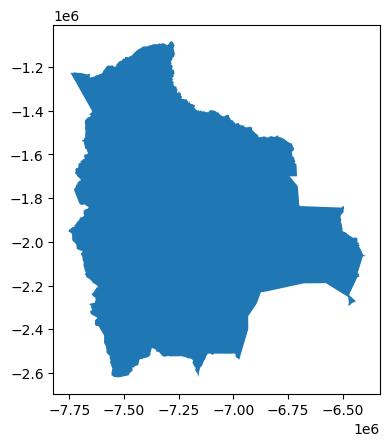

In [40]:
# plot Bolivia
gt_polygons.query('ADMIN == "Bolivia"').plot();

while Indonesia is a `MultiPolygon` containing many `Polygons` for each individual island in the country:

In [41]:
gt_polygons.query('ADMIN == "Indonesia"')

,ADMIN,geometry,centroid
0,Indonesia,"MULTIPOLYGON (((13102705.696 463877.598, 13102...",POINT (13055431.81 -248921.141)


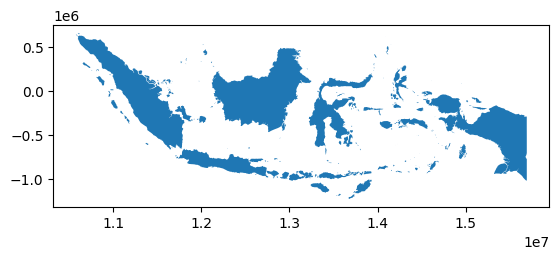

In [42]:
gt_polygons.query('ADMIN == "Indonesia"').plot();

:question: Query & then plot Pakistan.

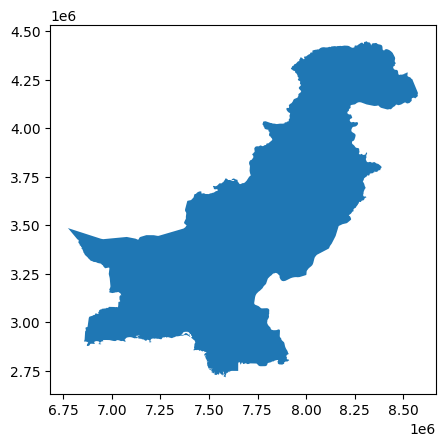

In [43]:
# Your code here
gt_polygons.query('ADMIN == "Pakistan"').plot();

In many cases, geographic tables will have geometries of a single type; records will *all* be `Point` or `LineString`, for instance. However, there is no formal requirement that a *geographic table* has geometries that all have the same type. 

Throughout this book, we will use geographic tables extensively, storing polygons, but also points and lines. We will explore lines a bit more in the second part of this chapter but, for now, let us stop on points for a second. As mentioned above, these are the simplest type of feature in that they do not have any dimension, only a pair of coordinates attached to them. This means that points can sometimes be stored in a non-geographic table, simply using one column for each coordinate. We find an example of this on the Tokyo dataset we will use more later. The data is stored as a comma-separated value table, or `.csv`:

In [44]:
gt_points = pandas.read_csv("../Course-Datasets/tokyo_clean.csv")

Since we have read it with `pandas`, the table is loaded as a `DataFrame`, with no explicit spatial dimension:

In [45]:
type(gt_points)

pandas.DataFrame

If we inspect the table, we find there is not a `geometry` column:

In [46]:
gt_points.head()

,user_id,longitude,latitude,date_taken,photo/video_page_url,x,y
0,10727420@N00,139.700499,35.674000,2010-04-09 17:26:25.0,http://www.flickr.com/photos/10727420@N00/4545...,1.555139e+07,4.255856e+06
1,8819274@N04,139.766521,35.709095,2007-02-10 16:08:40.0,http://www.flickr.com/photos/8819274@N04/26503...,1.555874e+07,4.260667e+06
2,62068690@N00,139.765632,35.694482,2008-12-21 15:45:31.0,http://www.flickr.com/photos/62068690@N00/3125...,1.555864e+07,4.258664e+06
3,49503094041@N01,139.784391,35.548589,2011-11-11 05:48:54.0,http://www.flickr.com/photos/49503094041@N01/6...,1.556073e+07,4.238684e+06
4,40443199@N00,139.768753,35.671521,2006-04-06 16:42:49.0,http://www.flickr.com/photos/40443199@N00/2482...,1.555899e+07,4.255517e+06


Many point datasets are provided in this format. To make the most of them, it is convenient to convert them into `GeoDataFrame` tables. There are two steps involved in this process. First, we turn the raw coordinates into geometries:

In [57]:
pt_geoms = geopandas.points_from_xy(
    x=gt_points["longitude"],
    y=gt_points["latitude"],
    # x,y are Earth longitude & latitude
    crs="EPSG:4326",
)

Second, we create a `GeoDataFrame` object using these geometries:

In [58]:
gt_points = geopandas.GeoDataFrame(gt_points, geometry=pt_geoms)

And now `gt_points` looks and feels exactly like the one of countries we have seen before, with the difference the `geometry` column stores `POINT` geometries:

In [59]:
gt_points.head()

,user_id,longitude,latitude,date_taken,photo/video_page_url,x,y,geometry
0,10727420@N00,139.700499,35.674000,2010-04-09 17:26:25.0,http://www.flickr.com/photos/10727420@N00/4545...,1.555139e+07,4.255856e+06,POINT (139.7005 35.674)
1,8819274@N04,139.766521,35.709095,2007-02-10 16:08:40.0,http://www.flickr.com/photos/8819274@N04/26503...,1.555874e+07,4.260667e+06,POINT (139.76652 35.7091)
2,62068690@N00,139.765632,35.694482,2008-12-21 15:45:31.0,http://www.flickr.com/photos/62068690@N00/3125...,1.555864e+07,4.258664e+06,POINT (139.76563 35.69448)
3,49503094041@N01,139.784391,35.548589,2011-11-11 05:48:54.0,http://www.flickr.com/photos/49503094041@N01/6...,1.556073e+07,4.238684e+06,POINT (139.78439 35.54859)
4,40443199@N00,139.768753,35.671521,2006-04-06 16:42:49.0,http://www.flickr.com/photos/40443199@N00/2482...,1.555899e+07,4.255517e+06,POINT (139.76875 35.67152)


--- 

In [50]:
# Check the number of rows & columsn for the dataset using .shape method
nrows_gt_points = gt_points.shape[0]
ncolumns_gt_points = gt_points.shape[1]
print(f"The number of rows in the dataframe are: {nrows_gt_points}")
print(f"The number of columns in the dataframe are: {ncolumns_gt_points}")

The number of rows in the dataframe are: 10000
The number of columns in the dataframe are: 8


In [51]:
# Choose a subset of the `gt_points` geoDataFrame; keep all columns though
gt_points_subset = gt_points.iloc[0:1000, :]

:question: Plot the dataset `gt_points_subset` with a basemap
> Use contextily.

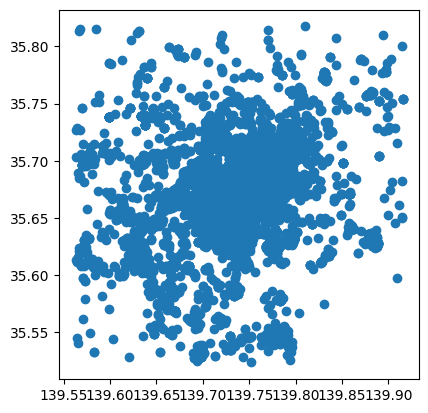

In [52]:
# Your code here!
gt_points.plot();

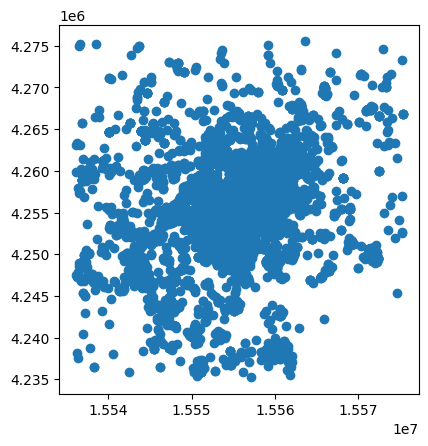

In [56]:
pt_geoms = geopandas.points_from_xy(
    x=gt_points["x"],
    y=gt_points["y"],
    # x,y are Earth longitude & latitude
    crs="EPSG:3857",
)
gt_points = geopandas.GeoDataFrame(gt_points, geometry=pt_geoms)
gt_points.head()
gt_points.plot();

## Find a UTM zone appropriate for the geoDataFrame `gt_points_subset`
> Use the method .estimate_utm_crs()

In [ ]:
# Your code here.

## Project the CRS of `gt_points_subset` to the UTM zone found above

In [ ]:
# Your code here.

## Plot the projected data frame

In [ ]:
# Your code here

:question: Do you observe any change?

Your answer here.

:question: Where can this approach fail?

Your answer here.

POINT (31.47996 74.34298)
Length of the line: 0.011466398524405313
Centroid of the line: POINT (31.47700270748542 74.34029566109645)
Area of the polygon: 9.546250000001174e-06
Perimeter of the polygon: 0.015519274046792863


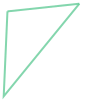

In [ ]:
from shapely.geometry import LineString, Polygon, Point, LinearRing, MultiLineString, MultiPolygon

Point1 = Point(31.47996, 74.34298)
Point2 = Point(31.47572, 74.33779) 
Point3 = Point(31.47593, 74.34255) 

print(Point1)

line = LineString([Point1, Point2, Point3])

length = line.length 

print("Length of the line:", length)

centroid = line.centroid
print("Centroid of the line:", centroid)

polygon = Polygon([Point1, Point2, Point3])

area = polygon.area
print("Area of the polygon:", area)

perimeter = polygon.length
print("Perimeter of the polygon:", perimeter)

line1 = LineString([Point1, Point2, Point3])
line2 = LineString([Point3, Point1])

multiline = MultiLineString([line1, line2])

multiline


